# ML by Karol Rejek

In [78]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

base_path = Path('content/drive/MyDrive/DataSets')
data_path = '/content/drive/MyDrive/DataSets/titanic.csv'
titanic_df = pd.read_csv(data_path, index_col='PassengerId')

In [81]:
def evaluate_hyperparameter(model_class, param_name, param_values, X_train, y_train, X_test, y_test, fixed_params=None):
    fixed_params = fixed_params or {}
    results = []
    for value in param_values:
        params = {**fixed_params, param_name: value}
        model = model_class(**params, random_state=42)
        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        results.append({
            param_name: value,
            'train_accuracy': accuracy_score(y_train, train_pred),
            'test_accuracy': accuracy_score(y_test, test_pred),
            'train_f1': f1_score(y_train, train_pred),
            'test_f1': f1_score(y_test, test_pred),
        })
    return pd.DataFrame(results)


def plot_hyperparameter_curve(results_df, param_name, metric='f1', none_replacement=None, log_scale=False):
    x = results_df[param_name].apply(lambda v: none_replacement if pd.isna(v) else v)
    plt.figure(figsize=(8, 5))
    plt.plot(x, results_df[f'train_{metric}'], marker='o', label=f'train {metric}')
    plt.plot(x, results_df[f'test_{metric}'], marker='o', label=f'test {metric}')
    plt.xlabel(param_name)
    plt.ylabel(metric)
    plt.title(f'{metric} vs {param_name}')
    plt.legend()
    plt.grid(True)
    if log_scale:
      plt.xscale('log')
    plt.show()

## Future Engenering danych

### Wnioski z poprzedniego zadania

Z tytułu w kolumnie `Name` wyodrębniłem status społeczny pasażera (Mr, Mrs, Miss...) - posłużył do trafniejszej imputacji brakującego wieku (mediana per grupa) oraz jako osobna cecha kategoryczna. Samą kolumnę Name usunąłem, ponieważ w surowej, tekstowej formie każda wartość jest praktycznie unikalna dla pasażera i nie niesie już żadnej dodatkowej informacji predykcyjnej ponad to, co wyekstrahowałem do statusu społecznego.

Przeżywalność względem wielkości rodziny (`FamilySize` = `SibSp` + `Parch` + 1) miała kształt odwróconej paraboli ze szczytem przy 4 osobach, dlatego zbinowałem ją na kategorie (Alone/Small/Large) zamiast zostawiać jako liczbę ciągłą. Kolumny `SibSp` i `Parch` usunąłem, bo ich informacja jest w pełni zawarta w `FamilySize`, a zostawienie wszystkich trzech wprowadzałoby zbędną redundancję.

Litera pokładu z `Cabin` w dużej mierze duplikowała `Pclass`, więc zamiast niej zostawiłem tylko binarną cechę `HasCabin` (sam fakt przypisania kabiny okazał się niezależnym predyktorem przeżywalności w obrębie każdej klasy), a oryginalną kolumnę Cabin usunąłem jako nadmiarową.

`Ticket` zamieniłem na `TicketGroupSize` (liczebność grupy biletowej) i usunąłem oryginał, ponieważ surowy numer biletu sam w sobie jest identyfikatorem bez wartości predykcyjnej - liczy się tylko to, ile osób go współdzieli.

`Fare` i `FarePerPerson` były silnie skorelowane ze swoimi wersjami logarytmicznymi, więc do modelu wybrałem log-wersje, żeby ograniczyć skośność rozkładu.

In [82]:
titanic_df['SocialStatus'] = titanic_df['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()
social_status_map = {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
titanic_df['SocialStatus'] = titanic_df['SocialStatus'].replace(social_status_map)
titanic_df.drop(columns=['Name'], inplace=True)

social_group_map = {
    'Mr': 'Commoner', 'Miss': 'Commoner', 'Mrs': 'Commoner', 'Master': 'Commoner',
    'Dr': 'Professional/Clergy', 'Rev': 'Professional/Clergy',
    'Col': 'Military/Nobility', 'Major': 'Military/Nobility', 'Capt': 'Military/Nobility',
    'Don': 'Military/Nobility', 'Sir': 'Military/Nobility', 'Lady': 'Military/Nobility',
    'Jonkheer': 'Military/Nobility', 'the Countess': 'Military/Nobility'
}
titanic_df['SocialGroup'] = titanic_df['SocialStatus'].map(social_group_map)
social_group_order = ['Commoner', 'Professional/Clergy', 'Military/Nobility']
titanic_df['SocialGroup'] = pd.Categorical(titanic_df['SocialGroup'], categories=social_group_order)
titanic_df = pd.get_dummies(titanic_df, columns=['SocialGroup'], prefix='SocialGroup', drop_first=True)

titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1
titanic_df.drop(columns=['SibSp', 'Parch'], inplace=True)
titanic_df['FamilySizeCategory'] = pd.cut(titanic_df['FamilySize'], bins=[0, 1, 4, np.inf], labels=['Alone', 'Small', 'Large'])
titanic_df = pd.get_dummies(titanic_df, columns=['FamilySizeCategory'], prefix='FamilySizeCategory', drop_first=True)

titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})
titanic_df['HasCabin'] = titanic_df['Cabin'].notna().astype(int)
titanic_df.drop(columns=['Cabin'], inplace=True)

train_df, test_df = train_test_split(titanic_df, test_size=0.2, stratify=titanic_df['Survived'], random_state=42)
train_df = train_df.copy()
test_df = test_df.copy()

age_medians = train_df.groupby('SocialStatus')['Age'].median()
global_age_median = train_df['Age'].median()
for df in (train_df, test_df):
    df['Age'] = df['Age'].fillna(df['SocialStatus'].map(age_medians).fillna(global_age_median))

train_df.drop(columns=['SocialStatus'], inplace=True)
test_df.drop(columns=['SocialStatus'], inplace=True)

ticket_counts_train = train_df['Ticket'].value_counts()
train_df['TicketGroupSize'] = train_df['Ticket'].map(ticket_counts_train)
ticket_counts_test = test_df['Ticket'].value_counts()
test_df['TicketGroupSize'] = test_df['Ticket'].map(ticket_counts_train).fillna(test_df['Ticket'].map(ticket_counts_test))

for df in (train_df, test_df):
    df['FarePerPerson'] = df['Fare'] / df['TicketGroupSize']

fpp_medians = train_df.groupby('Pclass')['FarePerPerson'].median()
global_fpp_median = train_df['FarePerPerson'].median()
for df in (train_df, test_df):
    missing_before = df['FarePerPerson'].isna()
    df['FarePerPerson'] = df['FarePerPerson'].fillna(df['Pclass'].map(fpp_medians).fillna(global_fpp_median))
    df.loc[missing_before, 'Fare'] = df.loc[missing_before, 'FarePerPerson'] * df.loc[missing_before, 'TicketGroupSize']

for df in (train_df, test_df):
    df['Fare_log'] = np.log1p(df['Fare'])
    df['FarePerPerson_log'] = np.log1p(df['FarePerPerson'])

embarked_mode = train_df['Embarked'].mode()[0]
embarked_categories = ['C', 'Q', 'S']
for df in (train_df, test_df):
    df['Embarked'] = pd.Categorical(df['Embarked'].fillna(embarked_mode), categories=embarked_categories)

train_df = pd.get_dummies(train_df, columns=['Embarked'], prefix='Embarked', drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Embarked'], prefix='Embarked', drop_first=True)

train_df.drop(columns=['Ticket'], inplace=True)
test_df.drop(columns=['Ticket'], inplace=True)

In [83]:
print(train_df.isna().sum()[train_df.isna().sum() > 0])
print(test_df.isna().sum()[test_df.isna().sum() > 0])

Series([], dtype: int64)
Series([], dtype: int64)


In [84]:
print(train_df.columns.tolist())
print(train_df.shape, test_df.shape)

['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'SocialGroup_Professional/Clergy', 'SocialGroup_Military/Nobility', 'FamilySize', 'FamilySizeCategory_Small', 'FamilySizeCategory_Large', 'HasCabin', 'TicketGroupSize', 'FarePerPerson', 'Fare_log', 'FarePerPerson_log', 'Embarked_Q', 'Embarked_S']
(712, 17) (179, 17)


## Baseline

In [85]:
y_train = train_df['Survived']
X_train = train_df.drop(columns='Survived')
y_test = test_df['Survived']
X_test = test_df.drop(columns='Survived')

In [86]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [87]:
from sklearn.dummy import DummyClassifier

for strategy in ['most_frequent', 'stratified', 'uniform']:
    dummy = DummyClassifier(strategy=strategy, random_state=42)
    dummy.fit(X_train, y_train)
    y_pred = dummy.predict(X_test)
    print(f'--- {strategy} ---')
    print(classification_report(y_test, y_pred))

--- most_frequent ---
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       110
           1       0.00      0.00      0.00        69

    accuracy                           0.61       179
   macro avg       0.31      0.50      0.38       179
weighted avg       0.38      0.61      0.47       179

--- stratified ---
              precision    recall  f1-score   support

           0       0.60      0.64      0.62       110
           1       0.37      0.33      0.35        69

    accuracy                           0.52       179
   macro avg       0.48      0.48      0.48       179
weighted avg       0.51      0.52      0.52       179

--- uniform ---
              precision    recall  f1-score   support

           0       0.61      0.47      0.53       110
           1       0.38      0.52      0.44        69

    accuracy                           0.49       179
   macro avg       0.50      0.50      0.49       179
weighted avg     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Najlepsze accuracy (0.61) daje strategia `most_frequent`, bo w zbiorze dominują osoby, które nie przeżyły (~61%), ale jej F1 macro (0.38) jest fatalne, bo model całkowicie ignoruje klasę 1. Pokazuje to, że przy niezbalansowanych klasach samo accuracy bywa mylące. Dlatego baseline (F1 macro ~0.38-0.48) jest dla mnie punktem odniesienia, który modele muszą wyraźnie przebić.

## Decision Tree

In [88]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.83      0.75      0.78       110
           1       0.65      0.75      0.70        69

    accuracy                           0.75       179
   macro avg       0.74      0.75      0.74       179
weighted avg       0.76      0.75      0.75       179



array([[82, 28],
       [17, 52]])

In [89]:
y_pred_train = model.predict(X_train)
print(classification_report(y_train, y_pred_train))
confusion_matrix(y_train, y_pred_train)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       439
           1       1.00      0.97      0.98       273

    accuracy                           0.99       712
   macro avg       0.99      0.98      0.99       712
weighted avg       0.99      0.99      0.99       712



array([[438,   1],
       [  8, 265]])

### Wpływ `max_depth` na wynik modelu

Analiza tego, jak zmienia się F1-score na zbiorze treningowym i testowym w zależności od maksymalnej głębokości drzewa decyzyjnego.

In [90]:
from sklearn.metrics import accuracy_score, f1_score

depths = [2, 3, 4, 5, 6, 8, 10, None]
results = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    train_pred = dt.predict(X_train)
    test_pred = dt.predict(X_test)

    results.append({
        'max_depth': depth,
        'train_accuracy': accuracy_score(y_train, train_pred),
        'test_accuracy': accuracy_score(y_test, test_pred),
        'train_f1': f1_score(y_train, train_pred),
        'test_f1': f1_score(y_test, test_pred),
    })

results_df = pd.DataFrame(results)
print(results_df)

   max_depth  train_accuracy  test_accuracy  train_f1   test_f1
0        2.0        0.789326       0.776536  0.634146  0.607843
1        3.0        0.830056       0.798883  0.769524  0.723077
2        4.0        0.848315       0.776536  0.790698  0.672131
3        5.0        0.869382       0.776536  0.812121  0.661017
4        6.0        0.886236       0.798883  0.834356  0.689655
5        8.0        0.919944       0.815642  0.888016  0.736000
6       10.0        0.945225       0.787709  0.924565  0.720588
7        NaN        0.987360       0.748603  0.983302  0.697987


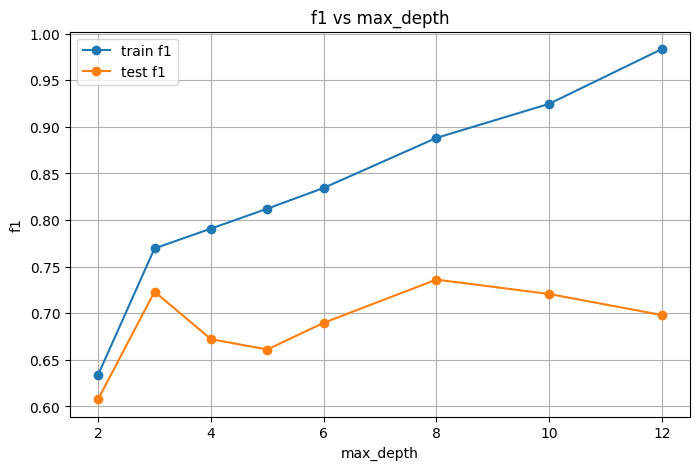

In [91]:
results_df = evaluate_hyperparameter(DecisionTreeClassifier, 'max_depth', [2, 3, 4, 5, 6, 8, 10, None], X_train, y_train, X_test, y_test)
plot_hyperparameter_curve(results_df, 'max_depth', metric='f1', none_replacement=12)

`train_f1` rośnie właściwie bez zaskoczeń — im głębsze drzewo, tym lepiej radzi sobie na danych, na których się uczyło, aż w końcu przy nieograniczonej głębokości niemal je "zapamiętuje" (F1 blisko 1.00). Ciekawiej robi się na zbiorze testowym, gdzie zamiast równie gładkiego wzrostu widać wyraźne wahania. Na samym początku widać wzrost do głębokości 3, potem chwilowy spadek przy 4-5, aż w końcu przy `max_depth=8`, model osiąga swój szczytowy wynik dla (F1 ≈ 0.736). Dalsze zwiększanie głębokości nie wpływa pozytywnie na model. Wynik na `test_f1` zaczyna się osuwać, choć na `train_f1` wciąż pnie się w górę. Ten narastający rozdźwięk między obiema krzywymi może obrazować przetrenowanie modelu, najsilniej jest on widoczny przy `max_depth=None`, gdzie dzieli je aż 0.28 punktu F1.

### Wpływ `min_samples_split` na wynik modelu

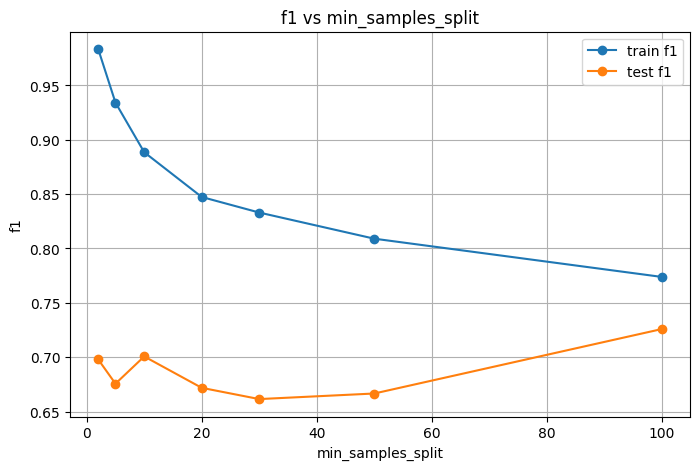

In [92]:
results_df_mss = evaluate_hyperparameter(
    DecisionTreeClassifier, 'min_samples_split',
    [2, 5, 10, 20, 30, 50, 100],
    X_train, y_train, X_test, y_test
)
plot_hyperparameter_curve(results_df_mss, 'min_samples_split', metric='f1')

`Train_F1` maleje monotonicznie z 0.98 do 0.78 wraz ze wzrostem `min_samples_split`. `Test F1` natommiast zachowuje się jednak nietypowo, spada z 0.70 do minimum ok. 0.66 w okolicach 20-30, po czym rośnie do 0.73 przy wartości 100. Ponieważ `max_depth` pozostaje tu nieograniczone, to `min_samples_split` musi samodzielnie hamować rozrost drzewa, więc dopiero jego wysokie wartości skutecznie ograniczają przetrenowanie.

### Strojenie hiperparametrów przez kroswalidację

W celu lepszego obrazu i dobrania parametrów sprawdzam `max_depth` i `min_samples_split` przez 5-krotną kroswalidację na zbiorze `train`, oceniając modele metryką F1.

In [93]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, None],
    'min_samples_split': [2, 5, 10, 20],
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score F1:", grid_search.best_score_)

Best Parameters: {'max_depth': 9, 'min_samples_split': 10}
Best Score F1: 0.7403592727315021


Wyniki wskazują `max_depth=9` i `min_samples_split=10` jako najlepszą kombinację (F1 ≈ 0.740). To bardzo blisko tego, co wyszło z wcześniejszych obserwacji (`max_depth=8`, F1 ≈ 0.736). Umacnia to wybór hiperparametrów jako sensowny.

In [94]:
best_tree = grid_search.best_estimator_
y_pred_best = best_tree.predict(X_test)
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.81      0.84      0.83       110
           1       0.73      0.70      0.71        69

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [95]:
results = pd.DataFrame(grid_search.cv_results_)
results = results[['param_max_depth', 'param_min_samples_split', 'mean_test_score', 'std_test_score']]
results.sort_values('mean_test_score', ascending=False).head(10)

,param_max_depth,param_min_samples_split,mean_test_score,std_test_score
26,9,10,0.740359,0.050224
22,8,10,0.739901,0.039677
20,8,2,0.738944,0.038112
21,8,5,0.738049,0.049463
24,9,2,0.734497,0.047247
12,6,2,0.734261,0.037354
30,10,10,0.732984,0.042623
16,7,2,0.732643,0.044552
23,8,20,0.731426,0.038081
27,9,20,0.731201,0.043854


Model z najlepszymi parametrami osiąga na zbiorze `test` accuracy 0.78 i `F1` macro 0.77, jest to wyraźnie lepiej niż baseline. Warto jednak zauwarzyć, że różnica `F1` między 1. a 10. miejscem w rankingu to zaledwie ok. 0.009, podczas gdy odchylenie standardowe wyniku najlepszej kombinacji wynosi aż 0.050. Te ustawienia praktycznie się więc nie różnią, a wyższość `max_depth=9`/`min_samples_split=10` mieści się w granicach losowego szumu kroswalidacji.

## SVM

In [96]:
from sklearn.svm import SVC

model_1 = SVC(random_state=42)
model_1.fit(X_train, y_train)
y_pred = model_1.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.90      0.77       110
           1       0.67      0.32      0.43        69

    accuracy                           0.68       179
   macro avg       0.67      0.61      0.60       179
weighted avg       0.67      0.68      0.64       179



In [97]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [98]:
model_2 = SVC(random_state=42)
model_2.fit(X_train_scaled, y_train)
y_pred = model_2.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.87      0.85       110
           1       0.77      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



Standaryzacja danych ma ogromny wpływ na jakość SVM. Bez niej model osiąga F1 macro 0.60 i wykrywa zaledwie 32% ocalałych pasażerów (recall klasy 1), może być to spowodowane zdominowaniem przez cechy o dużej skali liczbowej, niezależnie od ich rzeczywistego znaczenia predykcyjnego. Po zastosowaniu `StandardScaler` F1 macro rośnie do 0.79, a recall dla klasy 1 do 0.70. Dowodzi to, dlaczego modele oparte na odległościach/marginesach, w przeciwieństwie do drzew decyzyjnych gdzie nie występował ten problem, wymagają standaryzacji cech wejściowych.

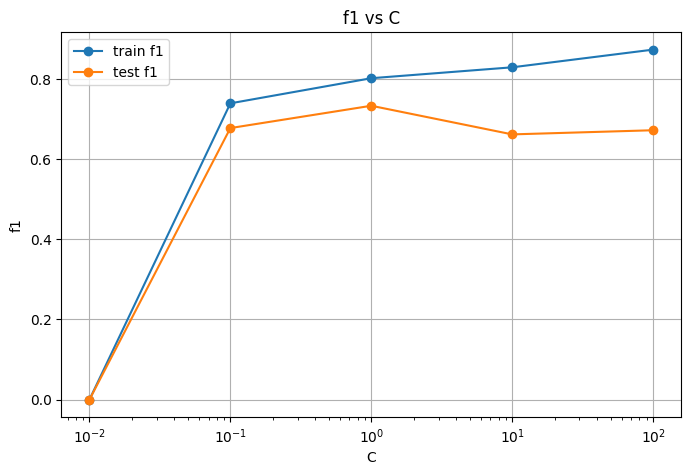

In [99]:
results_svm_C = evaluate_hyperparameter(SVC, 'C', [0.01, 0.1, 1, 10, 100],X_train_scaled, y_train, X_test_scaled, y_test)

plot_hyperparameter_curve(results_svm_C, 'C', metric='f1', log_scale=True)

Krzywa `C` pokazuje wyraźne przejście od skrajnego niedotrenowania (`C=0.01`, F1=0 na obu zbiorach) do sensownie działającego modelu już przy `C=0.1`. Najlepszy wynik na `test_f1` (F1≈0.73) osiąga `C=1`, po czym dalsze zwiększanie `C` poprawia jedynie dopasowanie do treningu (F1 rośnie do 0.87 przy C=100), a wynik na `test` stopniowo się pogarsza. Może to sygnalizować przetrenowanie, choć wyraźnie łagodniejsze niż w przypadku drzewa decyzyjnego bez ograniczenia głębokości.

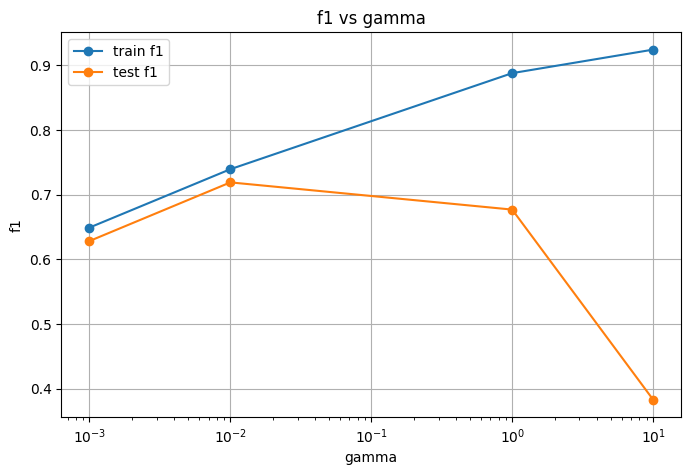

In [100]:
result_svc_gamma = evaluate_hyperparameter(SVC, 'gamma', [0.001, 0.01, 1, 10], X_train_scaled, y_train, X_test_scaled, y_test)

plot_hyperparameter_curve(result_svc_gamma, 'gamma', metric='f1', log_scale=True)

Z wyników można wywnioskować, że `gamma` okazuje się znacznie bardziej wrażliwy na przetrenowanie niż `C`. Najlepszy wynik na `test_f1` (F1≈0.72) daje `gamma=0.01`, a już przy `gamma=10` model kompletnie traci zdolność generalizacji (test F1 spada do 0.38, poniżej wyniku losowego baseline'u), mimo że na `train_f1` wynik dalej rośnie (F1≈0.92).

In [101]:
from sklearn.model_selection import GridSearchCV

param_grid_svm = {
    'C': [0.1, 0.5, 1, 5, 10],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1],
}

grid_search_svm = GridSearchCV(SVC(random_state=42), param_grid_svm, cv=5, scoring='f1')
grid_search_svm.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search_svm.best_params_)
print("Best Score F1:", grid_search_svm.best_score_)

Best Parameters: {'C': 1, 'gamma': 'scale'}
Best Score F1: 0.7577497777991518


In [102]:
best_svm = grid_search_svm.best_estimator_
y_pred_best_svm = best_svm.predict(X_test_scaled)
print(classification_report(y_test, y_pred_best_svm))

              precision    recall  f1-score   support

           0       0.82      0.87      0.85       110
           1       0.77      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [103]:
results_svm = pd.DataFrame(grid_search_svm.cv_results_)
results_svm = results_svm[['param_C', 'param_gamma', 'mean_test_score', 'std_test_score']]
results_svm.sort_values('mean_test_score', ascending=False).head(10)

,param_C,param_gamma,mean_test_score,std_test_score
10,1.0,scale,0.757750,0.034428
20,10.0,scale,0.750957,0.026912
18,5.0,0.1,0.750770,0.024973
15,5.0,scale,0.748721,0.026987
8,0.5,0.1,0.745312,0.044002
5,0.5,scale,0.744488,0.047009
22,10.0,0.01,0.742558,0.045898
13,1.0,0.1,0.740528,0.035807
23,10.0,0.1,0.738913,0.023033
17,5.0,0.01,0.737988,0.039316


Można zaobserwować, że najlepszy model SVM (C=1, gamma='scale') osiąga na teście accuracy 0.80 i F1 macro 0.79 co pokrywa się z wynikami modelu sprzed strojenia, co pokazuje, że domyślne parametry sklearn były już bliskie optimum dla tych danych. Różnica między najlepszą a dziesiątą kombinacją w rankingu (ok. 0.02 punktu F1) jest mniejsza niż odchylenie standardowe najlepszego wyniku (0.034). Sporo różnych kombinacji `C`/`gamma` w sprawdzonym zakresie działa praktycznie tak samo dobrze, a najlepszy wynik konkretnej pary to w dużej mierze kwestia szumu kroswalidacji.

In [104]:
y_pred_best_svm_train = best_svm.predict(X_train_scaled)
print(classification_report(y_train, y_pred_best_svm_train))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       439
           1       0.82      0.78      0.80       273

    accuracy                           0.85       712
   macro avg       0.84      0.84      0.84       712
weighted avg       0.85      0.85      0.85       712



Finalny model SVM (C=1, gamma='scale') osiąga F1 macro 0.84 na treningu i 0.79 na teście (różnica zaledwie 0.05 punktu). Pokazuje to, że margines decyzyjny SVM naturalnie ogranicza ryzyko przetrenowania, w przeciwieństwie do drzewa, które bez regularyzacji potrafi dopasować się niemal idealnie do zbioru treningowego. Moim zdaniem model jest dobrze zbalansowany i nie wymaga dodatkowego przycinania złożoności.

## Podsumowanie

SVM (C=1, gamma='scale', ze standaryzacją) i Decision Tree (max_depth=9, min_samples_split=10) wyraźnie przewyższają baseline, przy czym SVM generalizuje stabilniej, różnica `train`/`test` F1 tylko 0.05 vs 0.28 dla nieograniczonego drzewa. Jak można zauwarzyć hiperparametry wchodzą w interakcję, więc GridSearchCV daje bardziej wiarygodny obraz niż strojenie pojedynczych parametrów osobno, a różnice między czołowymi kombinacjami w rankingu często mieszczą się w szumie kroswalidacji. SVM wydaje się lepszym wyborem dzięki stabilniejszej generalizacji, ale Decision Tree broni się jako opcja bardziej przejrzysta i łatwiejsza do wizualizacji.